#📌 Extracción

In [1]:
import requests
import json

# URL de la API
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

# Solicitud a la API
response = requests.get(url)

# Convertir a JSON
data = response.json()

# primer registro para verificar
print(data[0])  
     

{'customerID': '0002-ORFBO', 'Churn': 'No', 'customer': {'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}, 'phone': {'PhoneService': 'Yes', 'MultipleLines': 'No'}, 'internet': {'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'No'}, 'account': {'Contract': 'One year', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Mailed check', 'Charges': {'Monthly': 65.6, 'Total': '593.3'}}}


In [2]:
import pandas as pd
df= pd.DataFrame(data)

In [3]:
df.shape

(7267, 6)

In [4]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [5]:
df.dtypes

customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object

In [6]:
df.info

<bound method DataFrame.info of       customerID Churn                                           customer  \
0     0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1     0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2     0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3     0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4     0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   
...          ...   ...                                                ...   
7262  9987-LUTYD    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
7263  9992-RRAMN   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
7264  9992-UJOEL    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
7265  9993-LHIEB    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
7266  9995-HOTOH    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   

                                           

#🔧 Transformación

In [7]:
# Expandir las columnas que contienen diccionarios en nuevas columnas
df_expandir = pd.json_normalize(data)

In [8]:
# Ver nombres de columnas y tipos de datos
print("Columnas del DataFrame en los diccionarios:")
print(df_expandir.dtypes)
     

Columnas del DataFrame en los diccionarios:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object


In [9]:
# Revisar los nombres de columnas disponibles como "diccionario"
print("Diccionario de variables:")
for col in df_expandir.columns:
    print(f"- {col}")

Diccionario de variables:
- customerID
- Churn
- customer.gender
- customer.SeniorCitizen
- customer.Partner
- customer.Dependents
- customer.tenure
- phone.PhoneService
- phone.MultipleLines
- internet.InternetService
- internet.OnlineSecurity
- internet.OnlineBackup
- internet.DeviceProtection
- internet.TechSupport
- internet.StreamingTV
- internet.StreamingMovies
- account.Contract
- account.PaperlessBilling
- account.PaymentMethod
- account.Charges.Monthly
- account.Charges.Total


In [10]:
df_expandir.shape

(7267, 21)

In [11]:
df_expandir.info

<bound method DataFrame.info of       customerID Churn customer.gender  customer.SeniorCitizen  \
0     0002-ORFBO    No          Female                       0   
1     0003-MKNFE    No            Male                       0   
2     0004-TLHLJ   Yes            Male                       0   
3     0011-IGKFF   Yes            Male                       1   
4     0013-EXCHZ   Yes          Female                       1   
...          ...   ...             ...                     ...   
7262  9987-LUTYD    No          Female                       0   
7263  9992-RRAMN   Yes            Male                       0   
7264  9992-UJOEL    No            Male                       0   
7265  9993-LHIEB    No            Male                       0   
7266  9995-HOTOH    No            Male                       0   

     customer.Partner customer.Dependents  customer.tenure phone.PhoneService  \
0                 Yes                 Yes                9                Yes   
1            

In [12]:
df_expandir.dtypes

customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object

In [13]:
df_expandir.isnull()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7263,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7264,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7265,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Comprobación de incoherencias en los datos

In [14]:
duplicados = df_expandir.duplicated().sum()
print(f"\nNúmero de registros duplicados: {duplicados}")



Número de registros duplicados: 0


In [15]:

# Resumen en forma de diccionario
resumen = {
    col: {
        "nulos": int(df_expandir[col].isna().sum()),
        "vacios": int((df_expandir[col] == "").sum()) if df_expandir[col].dtype == "object" else 0
    }
    for col in df_expandir.columns
}

pd.DataFrame(resumen).T

,nulos,vacios
customerID,0,0
Churn,0,224
customer.gender,0,0
customer.SeniorCitizen,0,0
customer.Partner,0,0
customer.Dependents,0,0
customer.tenure,0,0
phone.PhoneService,0,0
phone.MultipleLines,0,0
internet.InternetService,0,0


In [16]:
#podemos ver las variables categoricas
categoricas = df_expandir.select_dtypes(include='object').columns

for col in categoricas:
    print(f"\nValores únicos en {col}:")
    print(df_expandir[col].unique())


Valores únicos en customerID:
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Valores únicos en Churn:
['No' 'Yes' '']

Valores únicos en customer.gender:
['Female' 'Male']

Valores únicos en customer.Partner:
['Yes' 'No']

Valores únicos en customer.Dependents:
['Yes' 'No']

Valores únicos en phone.PhoneService:
['Yes' 'No']

Valores únicos en phone.MultipleLines:
['No' 'Yes' 'No phone service']

Valores únicos en internet.InternetService:
['DSL' 'Fiber optic' 'No']

Valores únicos en internet.OnlineSecurity:
['No' 'Yes' 'No internet service']

Valores únicos en internet.OnlineBackup:
['Yes' 'No' 'No internet service']

Valores únicos en internet.DeviceProtection:
['No' 'Yes' 'No internet service']

Valores únicos en internet.TechSupport:
['Yes' 'No' 'No internet service']

Valores únicos en internet.StreamingTV:
['Yes' 'No' 'No internet service']

Valores únicos en internet.StreamingMovies:
['No' 'Yes' 'No internet service']

Valores únicos en a

## Manejo de inconsistencias

In [17]:
#podemos notar que en las variables categoricas existen mayusculas y minusculas, seria mas facil trabajar con minusculas

df_expandir.columns = [col.lower() for col in df_expandir.columns]

print("Columnas normalizadas:")
print(df_expandir.columns.tolist())

Columnas normalizadas:
['customerid', 'churn', 'customer.gender', 'customer.seniorcitizen', 'customer.partner', 'customer.dependents', 'customer.tenure', 'phone.phoneservice', 'phone.multiplelines', 'internet.internetservice', 'internet.onlinesecurity', 'internet.onlinebackup', 'internet.deviceprotection', 'internet.techsupport', 'internet.streamingtv', 'internet.streamingmovies', 'account.contract', 'account.paperlessbilling', 'account.paymentmethod', 'account.charges.monthly', 'account.charges.total']


In [18]:
import numpy as np

# Función de normalización binaria simple
def mapeos(serie):
    serie = serie.fillna("").astype(str).str.strip().str.lower()
    mapeo = {
        "yes": 1, "si": 1, "true": 1, "1": 1,
        "no": 0, "false": 0, "0": 0,
        "": -1, "nan": -1
    }
    return serie.map(lambda x: mapeo.get(x, -1))

# Columnas que se convierten a 0/1/-1
binarias = [
    "churn",
    "customer.partner",
    "customer.seniorcitizen",
    "customer.dependents",
    "phone.phoneservice",
    "account.paperlessbilling"
]

for col in binarias:
    if col in df_expandir.columns:
        df_expandir[col] = mapeos(df_expandir[col])

print("Conversión aplicada a columnas binarias.")
print(df_expandir[binarias].head(10))

Conversión aplicada a columnas binarias.
   churn  customer.partner  customer.seniorcitizen  customer.dependents  \
0      0                 1                       0                    1   
1      0                 0                       0                    0   
2      1                 0                       0                    0   
3      1                 1                       1                    0   
4      1                 1                       1                    0   
5      0                 0                       0                    1   
6      0                 1                       1                    0   
7      0                 1                       0                    0   
8      0                 0                       1                    0   
9      0                 1                       0                    1   

   phone.phoneservice  account.paperlessbilling  
0                   1                         1  
1                   1            

#📊 Carga y análisis

In [19]:
print("\nAnálisis descriptivo de las variables categóricas:\n")
print(df_expandir.describe(include=["object"]))


Análisis descriptivo de las variables categóricas:

        customerid customer.gender phone.multiplelines  \
count         7267            7267                7267   
unique        7267               2                   3   
top     9995-HOTOH            Male                  No   
freq             1            3675                3495   

       internet.internetservice internet.onlinesecurity internet.onlinebackup  \
count                      7267                    7267                  7267   
unique                        3                       3                     3   
top                 Fiber optic                      No                    No   
freq                       3198                    3608                  3182   

       internet.deviceprotection internet.techsupport internet.streamingtv  \
count                       7267                 7267                 7267   
unique                         3                    3                    3   
top             

In [20]:
# Análisis descriptivo de las variables numéricas
print("Análisis descriptivo de los datos numéricos:\n")
print(df_expandir.describe())

Análisis descriptivo de los datos numéricos:

             churn  customer.seniorcitizen  customer.partner  \
count  7267.000000             7267.000000       7267.000000   
mean      0.226366                0.162653          0.484106   
std       0.486627                0.369074          0.499782   
min      -1.000000                0.000000          0.000000   
25%       0.000000                0.000000          0.000000   
50%       0.000000                0.000000          0.000000   
75%       1.000000                0.000000          1.000000   
max       1.000000                1.000000          1.000000   

       customer.dependents  customer.tenure  phone.phoneservice  \
count          7267.000000      7267.000000         7267.000000   
mean              0.300124        32.346498            0.902711   
std               0.458343        24.571773            0.296371   
min               0.000000         0.000000            0.000000   
25%               0.000000         9.00000

###  Distribución de evasión

In [34]:
etiquetas = {0: "Permanece activo", 1: "Canceló", -1: "No definido"}
conteo_churn = df_expandir["churn"].map(etiquetas).value_counts()
print(conteo_churn)

churn
Permanece activo    5174
Canceló             1869
No definido          224
Name: count, dtype: int64


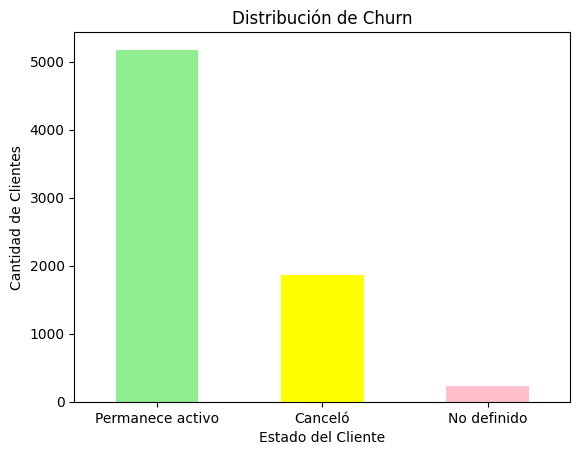

In [35]:
import matplotlib.pyplot as plt

conteo_churn.plot(kind="bar", color=["lightgreen","yellow","pink"])

plt.title("Distribución de Churn")
plt.xlabel("Estado del Cliente")
plt.ylabel("Cantidad de Clientes")
plt.xticks(rotation=0)

plt.show()

### Recuento de evasión por variables categóricas

<Figure size 800x600 with 0 Axes>

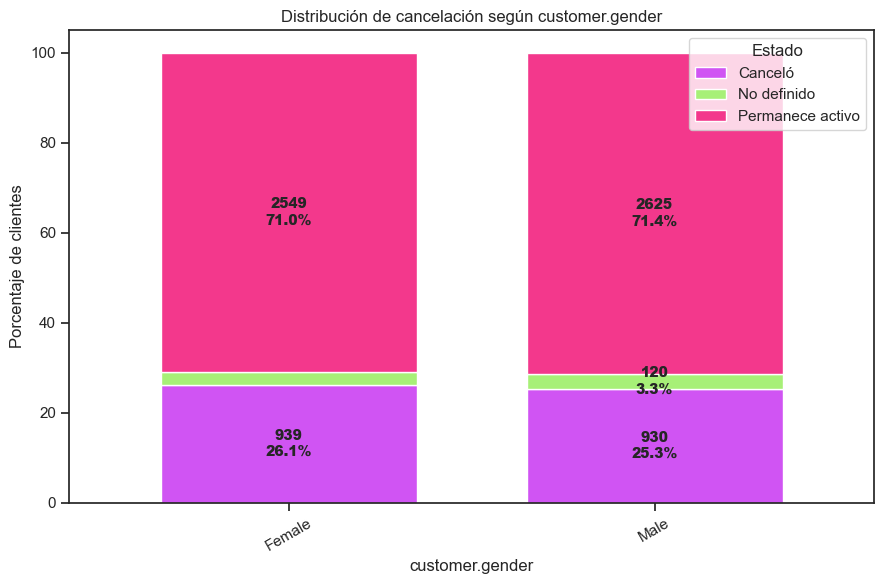

<Figure size 800x600 with 0 Axes>

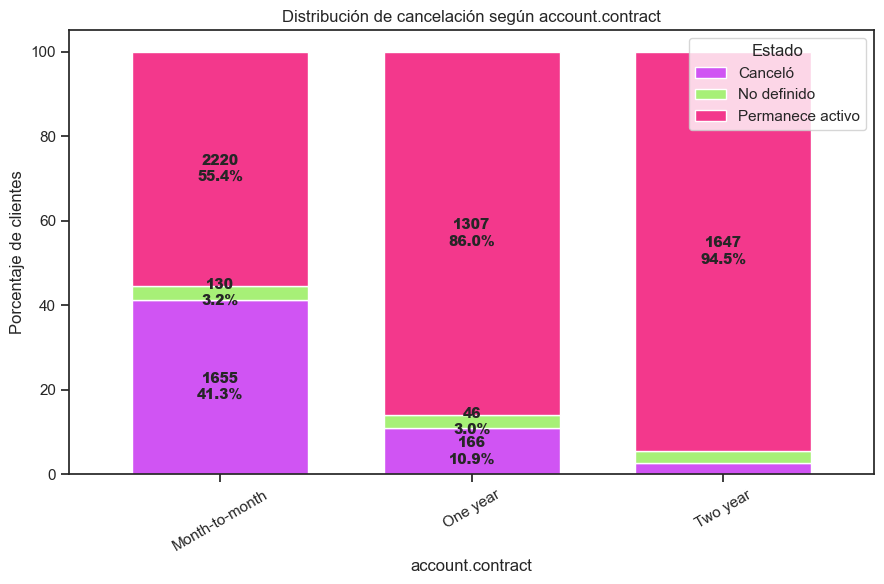

<Figure size 800x600 with 0 Axes>

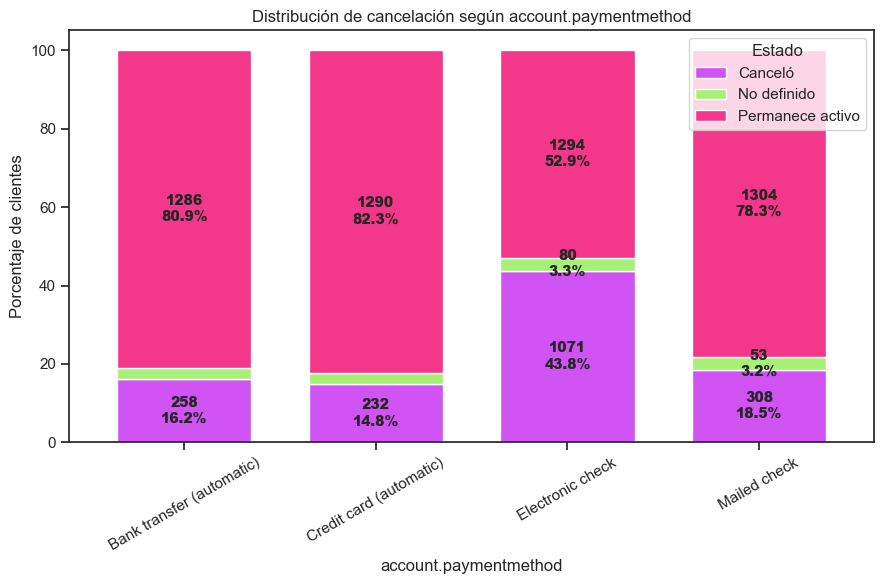

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt


# Estilo visual más profesional
sns.set_theme(style="ticks")
# Variables categóricas para el análisis de cancelación
categoricas = [
    "customer.gender",
    "account.contract",
    "account.paymentmethod"
]

# Reemplazar etiquetas de cancelación
etiquetas_cancelacion = {0: "Permanece activo", 1: "Canceló", -1: "No definido"}

for col in categoricas:
    plt.figure(figsize=(8, 6))

    # Tabla cruzada con conteo absoluto
    conteo = pd.crosstab(
        df_expandir[col],
        df_expandir["churn"].map(etiquetas_cancelacion)
    )

    # Tabla cruzada con porcentaje (normalizado por fila)
    porcentaje = pd.crosstab(
        df_expandir[col],
        df_expandir["churn"].map(etiquetas_cancelacion),
        normalize="index"
    ) * 100

    # Graficar porcentajes
    ax = porcentaje.plot(
        kind="bar", stacked=True,
        color= ["#D054F3", "#A7F077", "#F3388C"],
        figsize=(9,6),
        width=0.7
    )
    
    
     # Etiquetas dentro de las barras
    for i, categoria in enumerate(porcentaje.index):
        acumulado = 0
        for estado in porcentaje.columns:
            valor_abs = conteo.loc[categoria, estado]
            valor_pct = porcentaje.loc[categoria, estado]
            if valor_abs > 0 and valor_pct > 3:
                ax.text(
                    i,
                    acumulado + valor_pct/2,
                    f"{valor_abs}\n{valor_pct:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=10,
                    fontweight="black"
                )

            acumulado += valor_pct


    plt.title(f"Distribución de cancelación según {col}")
    plt.xlabel(col)
    plt.ylabel("Porcentaje de clientes")
    plt.legend(title="Estado", loc="upper right")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Conteo de evasión por variables numéricas

In [59]:
# Crear la columna 'cuenta.cuentas_diarias' a partir de 'cuenta.cargos_mensuales'
df_expandir["account.count_diaries"] = df_expandir["account.charges.monthly"] / 30

print("Columna 'cuenta.cuentas_diarias' creada exitosamente.")
print(df_expandir[["account.charges.monthly", "account.count_diaries"]].head(10))

Columna 'cuenta.cuentas_diarias' creada exitosamente.
   account.charges.monthly  account.count_diaries
0                    65.60               2.186667
1                    59.90               1.996667
2                    73.90               2.463333
3                    98.00               3.266667
4                    83.90               2.796667
5                    69.40               2.313333
6                   109.70               3.656667
7                    84.65               2.821667
8                    48.20               1.606667
9                    90.45               3.015000


In [77]:
# Asegurar que los cargos sean numéricos
df_expandir["account.charges.total"] = pd.to_numeric(
    df_expandir["account.charges.total"], errors="coerce"
)
df_expandir["account.charges.monthly"] = pd.to_numeric(
    df_expandir["account.charges.monthly"], errors="coerce"
)

# Mapear etiquetas legibles de cancelación
etiquetas_cancelacion = {0: "Activo", 1: "Canceló", -1: "No definido"}
df_temp = df_expandir.copy()
df_temp["churn"] = df_temp["churn"].map(etiquetas_cancelacion)

# Columnas numéricas relevantes
numericas = [
    "account.charges.total",
    "customer.tenure",
    "account.charges.monthly",
    "account.count_diaries"
]

# Agrupar y calcular estadísticas
comparacion = df_temp.groupby("churn")[numericas].agg(
    ["mean", "median", "std", "min", "max"]
).round(2)

print(comparacion)

            account.charges.total                                    \
                             mean   median      std    min      max   
churn                                                                 
Activo                    2555.34  1683.60  2329.46  18.80  8672.45   
Canceló                   1531.80   703.55  1890.82  18.85  8684.80   
No definido               2196.93  1163.18  2329.96  18.90  8425.30   

            customer.tenure                       account.charges.monthly  \
                       mean median    std min max                    mean   
churn                                                                       
Activo                37.57   38.0  24.11   0  72                   61.27   
Canceló               17.98   10.0  19.53   1  72                   74.44   
No definido           31.57   29.0  25.00   1  72                   63.41   

                                         account.count_diaries               \
            median    std    mi

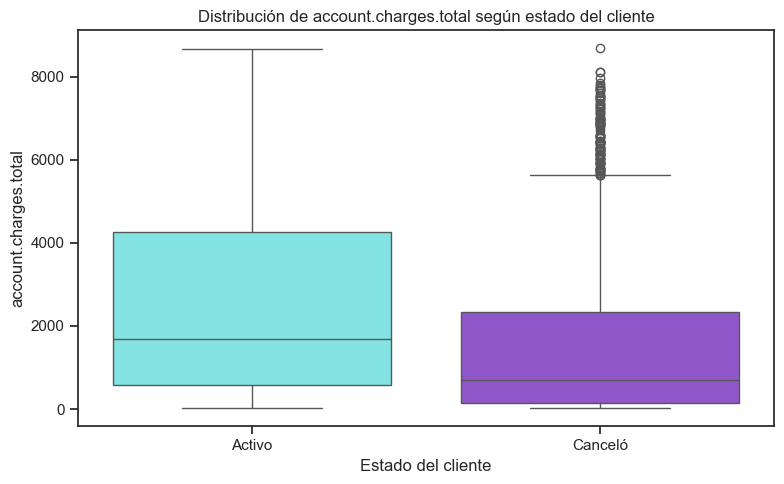

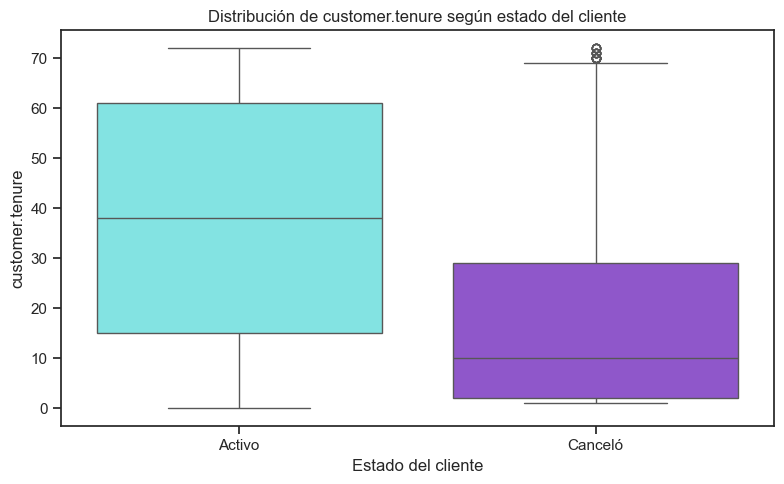

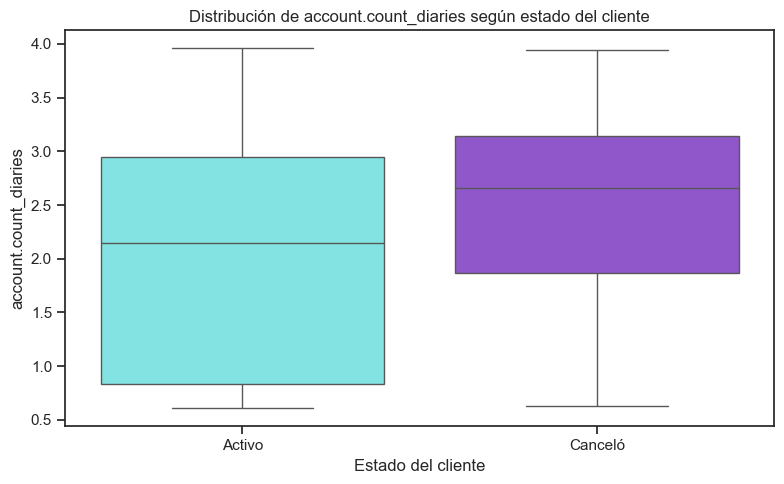

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Variables numéricas a analizar
numericas = [
    "account.charges.total",
    "customer.tenure",
    "account.count_diaries"
]

# Etiquetas de churn
etiquetas_cancelacion = {0: "Activo", 1: "Canceló"}

# Crear columna de estado
df_expandir["estado_cliente"] = df_expandir["churn"].map(etiquetas_cancelacion)

for col in numericas:

    # Verificar que la columna exista
    if col not in df_expandir.columns:
        print(f"La columna {col} no existe en el DataFrame")
        continue

    # Convertir a numérico si es necesario
    df_expandir[col] = pd.to_numeric(df_expandir[col], errors="coerce")

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df_expandir,
        x="estado_cliente",
        y=col,
        hue="estado_cliente",
        palette=["#73F3F1","#8E44DD"],
        legend=False
    )

    plt.title(f"Distribución de {col} según estado del cliente")
    plt.xlabel("Estado del cliente")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

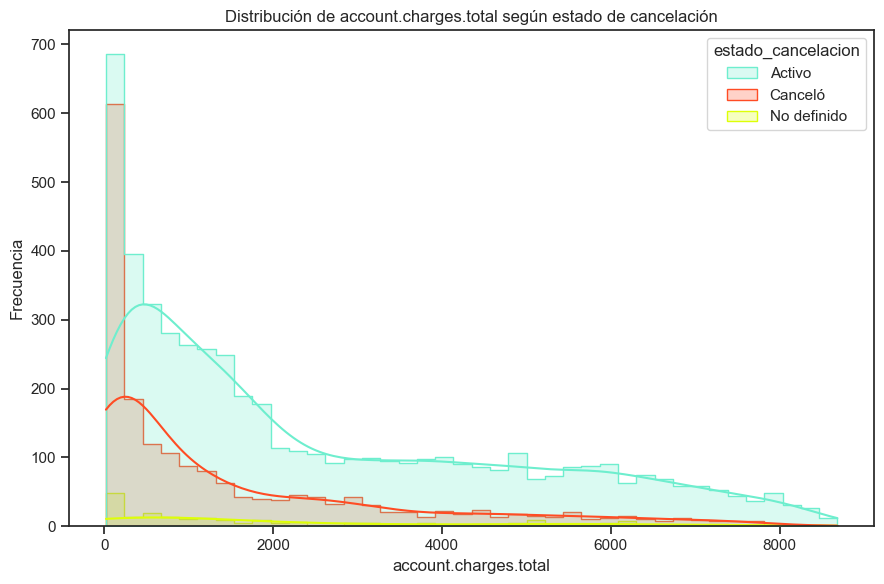

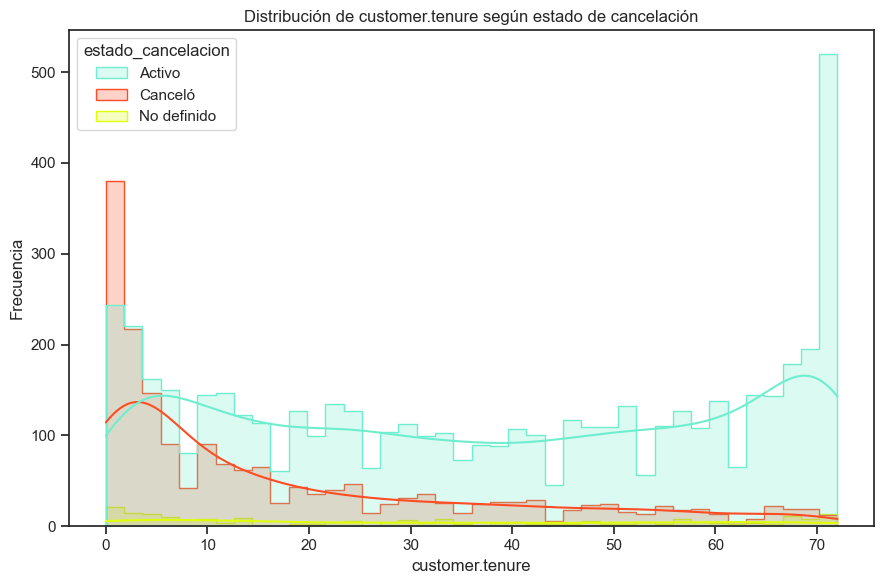

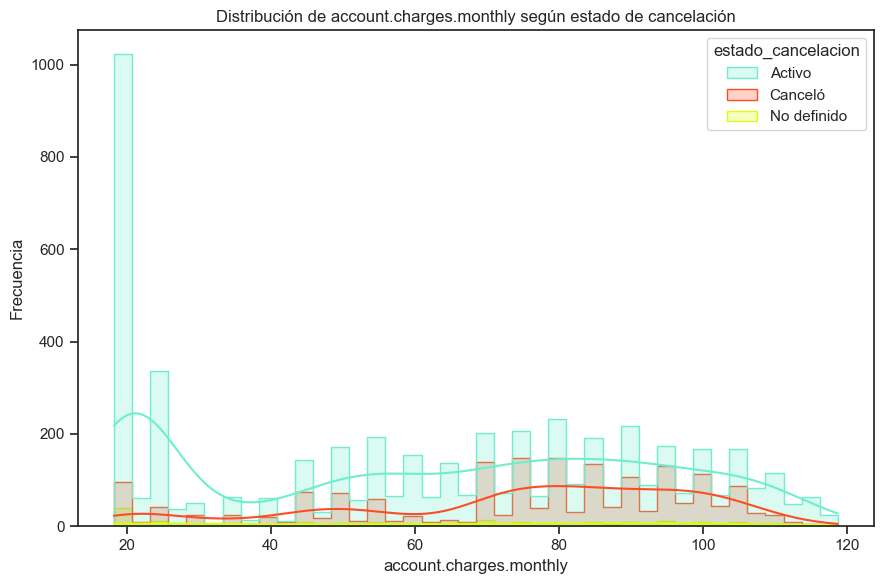

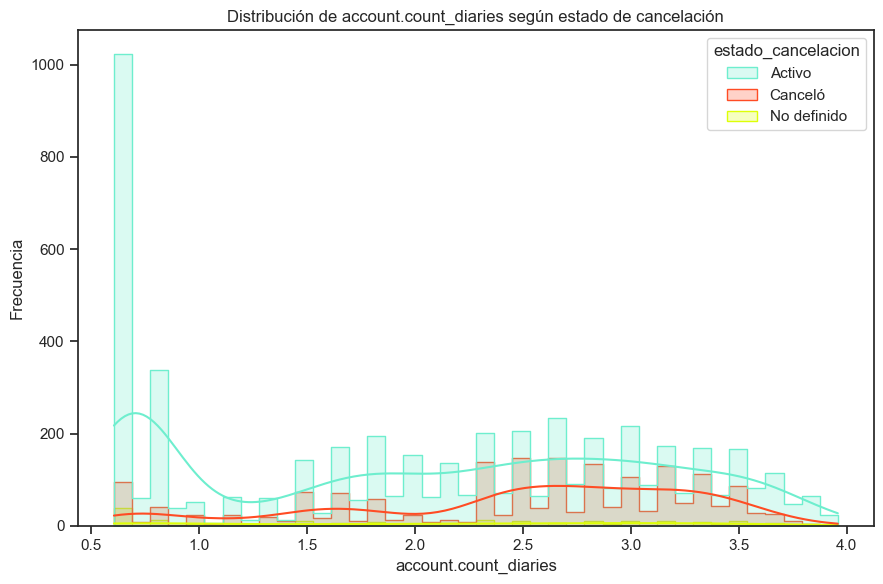

In [75]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

numericas = [
    "account.charges.total",
    "customer.tenure",
    "account.charges.monthly",
    "account.count_diaries"
]

# Mapear etiquetas de churn
etiquetas_cancelacion = {0: "Activo", 1: "Canceló", -1: "No definido"}
df_expandir["estado_cancelacion"] = df_expandir["churn"].map(etiquetas_cancelacion)

for col in numericas:

    # Verificar que la columna exista
    if col not in df_expandir.columns:
        print(f"La columna {col} no existe en el DataFrame")
        continue

    # Convertir a numérico por si hay valores tipo texto
    df_expandir[col] = pd.to_numeric(df_expandir[col], errors="coerce")

    plt.figure(figsize=(9,6))

    sns.histplot(
        data=df_expandir,
        x=col,
        hue="estado_cancelacion",
        kde=True,
        bins=40,
        palette=["#6EEECE", "#FF4C24", "#DEFF07" ],
        element="step"
    )

    plt.title(f"Distribución de {col} según estado de cancelación")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

#📄Informe final



El presente informe tiene como objetivo analizar la evasión de clientes (Churn) de Telecom-X.
El churn es un problema recurrente en las compañías de telecomunicaciones, ya que implica la pérdida de clientes hacia la competencia, lo que se traduce en disminución de ingresos y mayores costos de adquisición de nuevos usuarios.

Este análisis busca identificar los patrones de cancelación, variables críticas y factores de riesgo que influyen en la evasión, con el fin de proponer estrategias que permitan reducirla.


* 1) Extracción

Se utilizó un archivo JSON con los registros de clientes, importado directamente desde una API.
Los datos fueron normalizados a un DataFrame de Pandas.

* 2) Transformación

Expansión de campos anidados en subcolumnas (ejemplo: customer, phone, account)

Conversión de variables binarias a formato numérico (0 = No, 1 = Sí, -1 = No definido).

Creación de una variable derivada: a partir de account.charges.monthly / 30.

Manejo de inconsistencias y normalizamos los datos a minusculas, así como hacer una revisión de valores  de nulos y valores vacíos.

Conversión de columnas numéricas (cargos_totales, cargos_mensuales) a formato float.

* 3) Carga y análisis


**Distribución general del churn**

Se usaron graficas de barras para poder tener un medio visual más claro para observar los resultados,
más de 5000 clientes siguen activos y menos de 2000 de clientes canceló 



**Variables categóricas**

* Tipo de contrato: Los clientes con contrato Mes a mes presentan la tasa de cancelación más alta.
* Método de pago: El pago con Cheque electrónico se asocia a mayor cancelación, mientras que la tarjeta de credito muestra menor churn.
* Género: Si lo dividimos entre generos de femenino y masculino aproximadamente tienen un 71%  de permancer activos y solo un porcentaje de 25%-26%
ha cancelado.

**Variables numéricas**

Antigüedad: Los clientes con menor tiempo en la compañía tienen más probabilidades de cancelar.
Cargos mensuales: Los cargos más altos se relacionan con mayor churn, mientras que los cargos acumulados (cargos_totales) más bajos indican clientes recientes que abandonan pronto.
Visualizaciones


las gráficas de caja permitieron comparar la distribución de variables numéricas entre los clientes que permanecen activos y los que cancelaron el servicio.

Las variables analizadas incluyen:

* tiempo de contrato (tenure)

* cargos mensuales

* gasto total

* gasto diario aproximado

Los clientes que cancelaron el servicio tienden a tener menor antigüedad, mientras que los clientes activos presentan valores de tenure mucho más altos.

Esto indica que:

* la cancelación ocurre con mayor frecuencia en las primeras etapas del servicio

* los clientes que permanecen más tiempo tienden a seguir utilizando el servicio

**Cuentas diarias**

La variable de gasto diario estimado muestra una distribución similar a la de los cargos mensuales, aunque con menor dispersión. Esta variable permite observar el comportamiento de gasto de forma más granular, aunque su relación con la cancelación no es tan marcada como la del tiempo de contrato.

**Cargos mensuales**

En el caso de los cargos mensuales, se puede observar que algunos clientes que cancelaron presentan niveles relativamente altos de pago mensual.
Esto podría indicar que los precios elevados podrían influir en la decisión de cancelar el servicio, especialmente en clientes con contratos de corto plazo.

### CONCLUSIÓN
El análisis conjunto de las variables categóricas y numéricas sugiere que los factores más asociados con la cancelación de clientes son:

* Tipo de contrato, especialmente los contratos mensuales.

* Tiempo de permanencia en el servicio (tenure), donde los clientes más nuevos tienen mayor probabilidad de cancelar.

* Nivel de cargos mensuales, que podría influir en la decisión de abandonar el servicio.

En contraste, variables como género muestran poca influencia en la evasión de clientes.

Estos resultados proporcionan información valiosa para diseñar estrategias de retención, como incentivar contratos de mayor duración o implementar acciones de fidelización durante los primeros meses de servicio.

### RECOMENDACIONES

* Incentivar el uso de pagos automáticos por transferencia o tarjeta, que muestran menores tasas de churn.
* Fidelización de clientes nuevos: Implementar programas de bienvenida, beneficios iniciales y ofertas de permanencia para clientes con menos de 12 meses.
* Contratos más atractivos a largo plazo: Promover planes anuales o bianuales con descuentos o beneficios exclusivos.
Revisión de cargos mensuales
* Analizar si los planes de mayor costo generan una percepción de sobreprecio que incentive la fuga.
Optimización de métodos de pago

